---

# Predicting Car Fuel Efficiency with Linear Regression

Linear regression is one of the simplest and most interpretable machine learning algorithms. It models the relationship between a set of input features and a continuous target variable by fitting a straight line (or hyperplane in higher dimensions) through the data.

In this notebook, I apply linear regression to the Auto MPG dataset to predict a car's fuel efficiency (measured in miles per gallon) based on attributes like engine displacement, horsepower, and weight. This serves as a baseline model before moving on to more complex approaches.

---

In [27]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own LinearRegression implementation from ml_pack
from ml_pack import LinearRegression

# Sklearn tools for evaluation and preprocessing only
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

---

## Loading and Exploring the Data

Let's load the Auto MPG dataset and take a first look at its structure.

---

In [28]:
# Load the Auto MPG dataset
df = pd.read_csv("auto-mpg.csv")

# Check the dimensions of the dataset
print(df.shape)

# Preview the first few rows
df.head()

(398, 7)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


In [30]:
# Drop rows with missing values
df.dropna(inplace=True)

# Confirm the new shape after dropping missing rows
print(df.shape)

(396, 7)


---

## Defining Features and Target

We'll use `mpg` as our target variable and the remaining columns as input features.

---

In [31]:
# Define the target variable and features
target = 'mpg'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)

Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model-year']
Target: mpg


---

## Splitting and Scaling the Data

We split the data into training and test sets, then standardize the features so they're on the same scale. This helps the model treat all features equally regardless of their units.

---

In [32]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features - fit on training data only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (316, 6)
Test set size: (80, 6)


---

## Training the Model

We fit a linear regression model on the scaled training data.

---

In [33]:
# Initialize and train our custom linear regression model using OLS
model = LinearRegression(method='ols')
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


---

## Evaluating the Model

We evaluate the model on the test set using three common regression metrics: R², RMSE, and MAE.

---

In [34]:
# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
r2 = model.score(X_test_scaled, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score:  {r2:.3f}")
print(f"RMSE:      {rmse:.3f}")
print(f"MAE:       {mae:.3f}")

R² Score:  0.792
RMSE:      3.289
MAE:       2.535


---

## Visualizing Predictions

Let's plot the actual vs. predicted MPG values to see how well the model is performing.

---

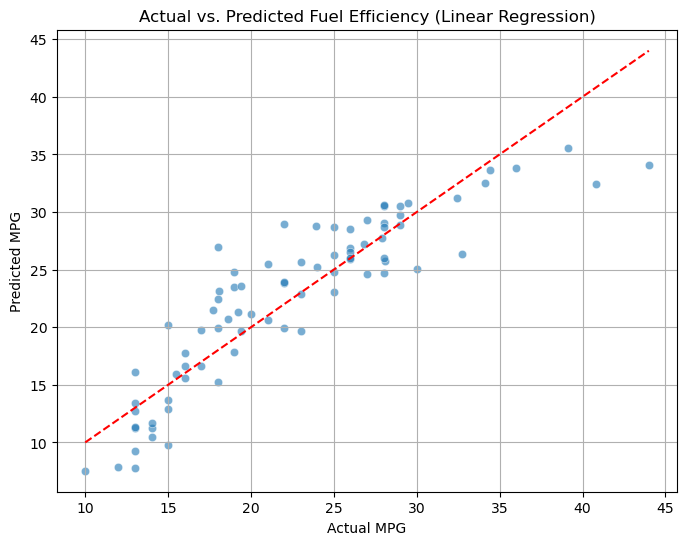

In [35]:
# Plot actual vs predicted MPG values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs. Predicted Fuel Efficiency (Linear Regression)")
plt.grid(True)
plt.show()

---

## Feature Importance

Linear regression assigns a coefficient to each feature, which tells us how much each variable contributes to the predicted MPG. A larger absolute value means a stronger influence on the prediction.

---

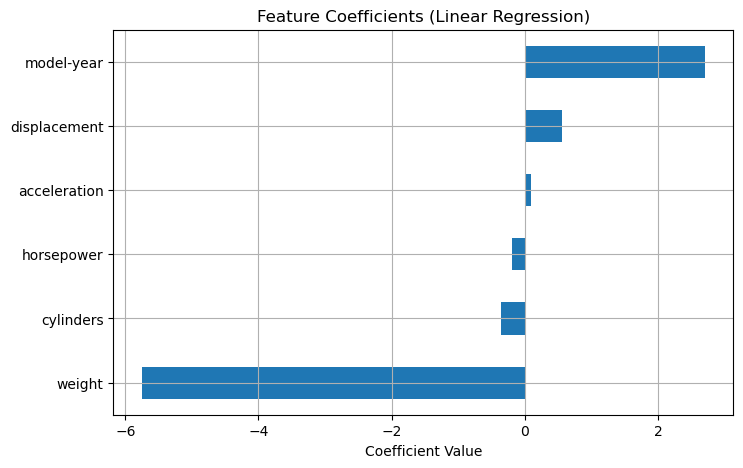

In [37]:
# Create a series of feature coefficients sorted by magnitude
feature_coefficients = pd.Series(model.weights, index=features)
feature_coefficients_sorted = feature_coefficients.sort_values()

# Plot the coefficients as a horizontal bar chart
plt.figure(figsize=(8, 5))
feature_coefficients_sorted.plot(kind='barh')
plt.title("Feature Coefficients (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.grid(True)
plt.show()

---

## Summary

In this notebook, we applied linear regression to predict car fuel efficiency using the Auto MPG dataset. The model achieved an R² of 0.792, meaning it explains roughly 79% of the variance in MPG.

From the feature coefficients, we can see that weight and displacement have the strongest negative influence on fuel efficiency — heavier, larger-engine cars tend to get worse mileage. Model year has a positive coefficient, reflecting improvements in fuel efficiency over time.

This notebook serves as a baseline. More complex models like ridge regression or gradient boosting could potentially improve performance further.

---